# Sentinel-2 NDMI/GNDVI analysis

Reproducible analysis accompanying:
[manuscript citation]

## Analysis workflow

1. Define Sentinel-2 acquisitions and study AOIs
2. Extract NDMI and GNDVI from each AOI
3. Identify cloudy acquisitions
4. Plot time series and weather data
5. Define dry seasons (1 March–30 June)
6. Perform BACI comparisons
7. Export manuscript analysis tables

In [18]:
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask

print(f"[Line {inspect.currentframe().f_lineno}] ...  Done with cell. ")

[Line 14] n_cols in ConstantObjects: 18
[Line 16] n_cols: 18, n_rows: 13
[Line 27] n_cols in ConstantObjects: 18
[Line 29] gdf_tree_circles.shape: (234, 1)
x0 =  -66983.49795860096
y0 =  6798562.116878612
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (51.990025, -0.599702)
x0 =  -68390.01972477396
y0 =  6800232.67711292
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (52.000240, -0.614569)
x0 =  -68390.01972477396
y0 =  6800232.67711292
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (52.000348, -0.614319)
x0 =  -68512.47116464656
y0 =  6800124.188707629
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (51.999571, -0.615646)
Constants.n_cols =  18
Constants.n_rows =  13
x0 =  -68390.01972477396
y0 =  6799654.0890871575
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (51.999119, -0.609507)
x0 =  -68796.33586616941
y0 =  6799925.297074551
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: 

In [25]:
import pandas as pd
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask

from IPython.display import display, HTML
display(HTML("<style>.jp-OutputArea {max-height: 200px}</style>"))


rows = []  # collect per-date stats here
#Some Sentinel2 overflight dates in veracruz are 2024-01-13, 2025-01-12
#Some Sentinel2 overflight dates in woburn are 2021-06-05 2023-06-05 2024-06-04 2025-06-04 2026-06-04
#startDate = "2026-06-04"
#endDate = "2026-08-31"
dates23 = Utils.generate_date_range("2023-06-05", "2023-08-31", Constants.lat0, Constants.lon0, "%Y-%m-%d")
dates24 = Utils.generate_date_range("2024-06-04", "2024-08-31", Constants.lat0, Constants.lon0, "%Y-%m-%d")
dates25 = Utils.generate_date_range("2025-06-04", "2025-08-31", Constants.lat0, Constants.lon0, "%Y-%m-%d")
dates26 = Utils.generate_date_range("2026-06-04", "2026-08-31", Constants.lat0, Constants.lon0, "%Y-%m-%d")
dates = dates26 + dates25 + dates24 + dates23
startDate = min(dates)
endDate = max(dates)
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")

# jan 12, no cloud directly over farm.
#Feb 11, lots of clouds over farm
ndmi_tile_tif=""
print(f"Cell [Line {inspect.currentframe().f_lineno}] ... dates = ",dates)
soil_mine_max_i =25     
for date in dates:
    
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date = ",date)
    gndvi_tile_tif = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "gndvi","tif")
    ndmi_tile_tif  = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "ndmi", "tif")

    if not os.path.exists(ndmi_tile_tif) or not os.path.exists(gndvi_tile_tif):
        print(
            f"Skipping {date}: derived NDMI/gNDVI missing "
            "(likely no Sentinel-2 acquisition for this tile/date)."
        )
        continue

    # The tile file may exist while this AOI lies in a black/no-data swath.
    ndmi_valid = Utils.valid_index_pixels_in_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_willow)   # gdf_box_willow replaces gdf_box_terreno_casa .. somewhat analogous to ARA
    gndvi_valid = Utils.valid_index_pixels_in_gdf(gndvi_tile_tif, ConstantObjects.gdf_box_willow) #
    if ndmi_valid == 0 or gndvi_valid == 0:
        print(f"Cell [Line {inspect.currentframe().f_lineno}] Skipping {date}: no valid gndvi or ndvi pixels over the willow AOI, file {ndmi_tile_tif} or {gndvi_tile_tif} "
              f"(NDMI={ndmi_valid}, GNDVI={gndvi_valid}).")
        Utils.cleanup_rejected_scene(date, Constants.lat0, Constants.lon0,reason="no valid gndvi or ndvi pixels over the willow AOI ",enabled=Constants.DELETE_REJECTED_DATE_FILES)
        continue

    rgb_tile_tif   = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb.uint8","tif")

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ndmi_tile_tif = ",ndmi_tile_tif)
    #gdf_box = ConstantObjects.gdf_box_terreno_casa
    ndmi_willow_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "willow","tif")

    b02_willow_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B02","jp2")
    b03_willow_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B03","jp2")
    b04_willow_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B04","jp2")
    if os.path.exists(b02_willow_jp2) and os.path.exists(b03_willow_jp2) and os.path.exists(b04_willow_jp2):
        print(f"[Line {inspect.currentframe().f_lineno}] ... found all three of B02,B03, and B04 .jp2 images. Moving forward. ")
    else:
        print(f"[Line {inspect.currentframe().f_lineno}] ... will have to try the next date, because unable to find files:  ", b02_willow_jp2 ," , " , b03_willow_jp2," , " , b04_willow_jp2  )
        continue #If we do not have all three files for this date we should move on to the next date.
    green_vs_red_blue = np.nan
    rgb_willow_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb-terreno-casa","tif")

    print(f"[Line {inspect.currentframe().f_lineno}] ... ndmi_willow_tif = ",ndmi_willow_tif)    
    # add up red intensity
    b2_intensity_willow = Utils.crop_and_sum_intensity(b02_willow_jp2, ConstantObjects.gdf_box_willow, scale_factor=None, clip_to_aoi_bounds=True)
    b3_intensity_willow = Utils.crop_and_sum_intensity(b03_willow_jp2, ConstantObjects.gdf_box_willow, scale_factor=None, clip_to_aoi_bounds=True)
    b4_intensity_willow = Utils.crop_and_sum_intensity(b04_willow_jp2, ConstantObjects.gdf_box_willow, scale_factor=None, clip_to_aoi_bounds=True)
    if any(band_stats["valid_pixels"] == 0 for band_stats in (
        b2_intensity_willow, b3_intensity_willow, b4_intensity_willow
    )):
        print(f"Cell [Line {inspect.currentframe().f_lineno}] Skipping {date}: an RGB band has no valid pixels over the AOI.")
        Utils.cleanup_rejected_scene(date, Constants.lat0, Constants.lon0,reason="No valid pixels over AOI.",enabled=Constants.DELETE_REJECTED_DATE_FILES)
        continue
    b2_norm_reflectance_willow = b2_intensity_willow["sum"]/b2_intensity_willow["valid_pixels"]
    b3_norm_reflectance_willow = b3_intensity_willow["sum"]/b3_intensity_willow["valid_pixels"]
    b4_norm_reflectance_willow = b4_intensity_willow["sum"]/b4_intensity_willow["valid_pixels"]
    red_green_blue_average = (b2_norm_reflectance_willow+b3_norm_reflectance_willow+b4_norm_reflectance_willow)/3 
    cloudy =0
    if (red_green_blue_average) > 2300:  cloudy = 1
    if cloudy:
        print(f"Cell [Line {inspect.currentframe().f_lineno}] Skipping {date}: RGB average {red_green_blue_average:.1f} "
              "exceeds the cloud threshold.")
        Utils.cleanup_rejected_scene(date, Constants.lat0, Constants.lon0,reason="exceeds the cloud threshold.",enabled=Constants.DELETE_REJECTED_DATE_FILES)
        continue
        
    print(
        date,
        "RGB avg =", red_green_blue_average,
        "cloudy =", cloudy,
        "NDMI exists =", os.path.exists(ndmi_tile_tif),
        "gNDVI exists =", os.path.exists(gndvi_tile_tif)
    )
    
    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_willow, ndmi_willow_tif) ")
    stats_willow = Utils.crop_ndmi_to_gdf(
        ndmi_tile_tif,
        ConstantObjects.gdf_box_willow,
        ndmi_willow_tif,
    )
    if stats_willow["count_valid"] == 0:
        print(f"Skipping {date}: neighboring AOI has no valid NDMI pixels.")
        Utils.cleanup_rejected_scene(date, Constants.lat0, Constants.lon0,reason="willow AOI has no valid NDMI pixels.",enabled=Constants.DELETE_REJECTED_DATE_FILES)
        continue
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")

    print("Avg NDMI over neighboring AOI:", stats_willow["mean"])
  
    print(f"[Line {inspect.currentframe().f_lineno}] ...  ")
        
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)
    ndmi_woburn_soil_mine_subplot_stats  =  {}
    gndvi_woburn_soil_mine_subplot_stats =  {}    
    try:
        ndmi_woburn_soil_mine_stats       =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_woburn_soil_mine,      ndmi_tile_tif, "ndmi_woburn_soil_mine",       date, cloudy)
        #ndmi_woburn_soil_mine_0_0_stats   =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_woburn_soil_mine_20x20(0,0),ndmi_tile_tif,"ndmi_woburn_soil_mine_20x20_0_0",date, cloudy)
        #i=18
        #for j in (-8,-7,-6,-5,-4,-3,-2,-1, 0,1,2,3,4): 
        #for j in range (1):
        #    ndmi_woburn_soil_mine_subplot_stats[i,j]  = Utils.get_stats_from_gdf(ConstantObjects.gdf_box_woburn_soil_mine_20x20(i, j), ndmi_tile_tif,   f"ndmi_woburn_soil_mine_subplot_{i}_{j}",   date,cloudy,)
        #    gndvi_woburn_soil_mine_subplot_stats[i,j] = Utils.get_stats_from_gdf(ConstantObjects.gdf_box_woburn_soil_mine_20x20(i, j), gndvi_tile_tif, f"gndvi_woburn_soil_mine_subplot_{i}_{j}",   date,cloudy,)
        j=0
        for i in range (soil_mine_max_i): ndmi_woburn_soil_mine_subplot_stats[i,j]  = Utils.get_stats_from_gdf(ConstantObjects.gdf_box_woburn_soil_mine_20x20(i, j), ndmi_tile_tif,   f"ndmi_woburn_soil_mine_subplot_{i}_{j}",   date,cloudy,)
        for i in range (soil_mine_max_i): gndvi_woburn_soil_mine_subplot_stats[i,j] = Utils.get_stats_from_gdf(ConstantObjects.gdf_box_woburn_soil_mine_20x20(i, j), gndvi_tile_tif, f"gndvi_woburn_soil_mine_subplot_{i}_{j}",   date,cloudy,)
      
        ndmi_willow_stats =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_willow,ndmi_tile_tif, "ndmi_willow", date, cloudy)
        ndmi_woburn_abbey_park_stats=            Utils.get_stats_from_gdf(ConstantObjects.gdf_box_woburn_abbey_park,ndmi_tile_tif,"ndmi_woburn_abbey_park",date, cloudy)
        gndvi_woburn_soil_mine_stats      =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_woburn_soil_mine,      gndvi_tile_tif,"gndvi_woburn_soil_mine",      date, cloudy)
        gndvi_willow_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_willow,gndvi_tile_tif,"gndvi_willow",date, cloudy)
        #gndvi_woburn_soil_mine_0_0_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_woburn_soil_mine_20x20(0,0),gndvi_tile_tif,"gndvi_woburn_soil_mine_20x20_0_0",date, cloudy)

        gndvi_woburn_abbey_park_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_woburn_abbey_park,gndvi_tile_tif,"gndvi_woburn_abbey_park",date, cloudy)
        #gndvi_milpa_vecino_stats   =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa_vecino,gndvi_tile_tif,"gndvi_milpa_vecino",date, cloudy)
    except ValueError as e:
        if "AOI does not overlap the raster" in str(e):
            print(f"Skipping {date}: {e}")
            continue
        raise
        
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_woburn_soil_mine_stats.get(mean,   np.nan) = ",gndvi_woburn_soil_mine_stats.get("mean",   np.nan))
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_willow_stats.get(mean,   np.nan) = ",gndvi_willow_stats.get("mean",   np.nan))


    row={
        "date": date,
        "gndvi_woburn_soil_mine": gndvi_woburn_soil_mine_stats.get("mean",   np.nan) ,
        "gndvi_willow":  gndvi_willow_stats.get("mean",   np.nan) ,
        "gndvi_woburn_abbey_park":gndvi_woburn_abbey_park_stats.get("mean",   np.nan) ,        
        "ndmi_woburn_soil_mine":  ndmi_woburn_soil_mine_stats.get ("mean",   np.nan) ,
        "ndmi_willow":   ndmi_willow_stats.get("mean",   np.nan) ,
        "ndmi_woburn_abbey_park": ndmi_woburn_abbey_park_stats.get("mean",   np.nan) ,        
        "red":           b2_norm_reflectance_willow,
        "green":         b3_norm_reflectance_willow,
        "blue":          b4_norm_reflectance_willow,
        "red_green_blue_average": red_green_blue_average,
        "cloudy" :       cloudy *1
    }  
    #ndmi_woburn_soil_mine_subplot_stats
    for (i, j), stats in gndvi_woburn_soil_mine_subplot_stats.items():
        # mean_center is an unweighted average over the values of pixels whose CENTER is inside the gdf box. weighted_mean is a weighted average over all pixels that overlap the gdf box, regardless of the size of that overlap.
        row[f"gndvi_woburn_soil_mine_subplot_{i}_{j}"] = stats.get("weighted_mean", np.nan)
    for (i, j), stats in ndmi_woburn_soil_mine_subplot_stats.items():
        row[f"ndmi_woburn_soil_mine_subplot_{i}_{j}"]  = stats.get("weighted_mean", np.nan)
    rows.append(row)
    
    print(f"[Line {inspect.currentframe().f_lineno}] ... Just appended to rows, an entry with date = ",date)
    print(f"[Cell Line {inspect.currentframe().f_lineno}] ... b2_intensity_willow[sum]  ",b2_intensity_willow["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b3_intensity_willow[sum]  ",b3_intensity_willow["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b4_intensity_willow[sum]  ",b4_intensity_willow["sum"])

    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(rgb_tile_tif, ConstantObjects.gdf_box_willow, rgb_willow_tif)  ")
 
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")

[Line 14] n_cols in ConstantObjects: 18
[Line 16] n_cols: 18, n_rows: 13
[Line 27] n_cols in ConstantObjects: 18
[Line 29] gdf_tree_circles.shape: (234, 1)
x0 =  -66983.49795860096
y0 =  6798562.116878612
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (51.990025, -0.599702)
x0 =  -68390.01972477396
y0 =  6800232.67711292
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (52.000240, -0.614569)
x0 =  -68390.01972477396
y0 =  6800232.67711292
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (52.000348, -0.614319)
x0 =  -68512.47116464656
y0 =  6800124.188707629
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (51.999571, -0.615646)
Constants.n_cols =  18
Constants.n_rows =  13
x0 =  -68390.01972477396
y0 =  6799654.0890871575
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (51.999119, -0.609507)
x0 =  -68796.33586616941
y0 =  6799925.297074551
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: 

[Line 506] ... Mapped latitude  52.000593 , longitude  -0.614358  to mgrs_tile =  30UXC
First acquisition: 2023-06-05
[Line 506] ... Mapped latitude  52.000593 , longitude  -0.614358  to mgrs_tile =  30UXC
First acquisition: 2024-06-04
[Line 506] ... Mapped latitude  52.000593 , longitude  -0.614358  to mgrs_tile =  30UXC
First acquisition: 2025-06-04
[Line 506] ... Mapped latitude  52.000593 , longitude  -0.614358  to mgrs_tile =  30UXC
First acquisition: 2026-06-04
[Line 31] ...   
Cell [Line 36] ... dates =  ['2026-06-04', '2026-06-09', '2026-06-14', '2026-06-19', '2026-06-24', '2026-06-29', '2026-07-04', '2026-07-09', '2026-07-14', '2026-07-19', '2026-07-24', '2026-07-29', '2026-08-03', '2026-08-08', '2026-08-13', '2026-08-18', '2026-08-23', '2026-08-28', '2025-06-04', '2025-06-09', '2025-06-14', '2025-06-19', '2025-06-24', '2025-06-29', '2025-07-04', '2025-07-09', '2025-07-14', '2025-07-19', '2025-07-24', '2025-07-29', '2025-08-03', '2025-08-13', '2025-08-18', '2025-08-23', '2025-

In [26]:
importlib.reload(Utils)

# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)    

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
with pd.option_context("display.max_columns", None, "display.width", None):
    print ("df = ",df)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)

df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#df = pd.DataFrame(rows)
print(df.columns.tolist())
print(df.head())
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

def to_mx_date(col):
    return pd.to_datetime(col, utc=True).dt.tz_convert("America/Mexico_City").dt.normalize()

# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
precip_df = Utils.daily_precip_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)
temp_df = Utils.daily_temp_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)

api_key = "E6RKNQ36BSLC8EUK5S3C5AKUQ"
location = str(Constants.lat0)+","+str(Constants.lon0) #"19.777411,-96.870102"  # Change location as needed
unit_group = "metric" 

visualcrossing_dict = Utils.fetch_weather_data(api_key, location, startDate, endDate, unit_group)

print ("**********************")

print(f"[Line {inspect.currentframe().f_lineno}] ...   ")
precip_df.head()
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
p = precip_df.copy()
p["date"] = p["date"].dt.tz_localize(None)
#p["date"] = pd.to_datetime(p["date"]).dt.normalize()
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

t = temp_df.copy()
t["date"] = pd.to_datetime(t["date"]).dt.tz_localize(None)
p = p.merge(t, on="date", how="left").sort_values("date")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# align daily precip with sparse NDMI, for excel:
out = p.merge(df, on="date", how="left")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# save for Excel
df.to_csv("daily_table.csv", index=False)
#out.to_csv("daily_table.csv", index=False)

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")


[Cell Line 6] .. 
df =            date  gndvi_woburn_soil_mine  gndvi_willow  gndvi_woburn_abbey_park  \
0   2026-06-19                0.277663      0.395035                 0.473424   
1   2026-06-24                0.249664      0.387287                 0.459237   
2   2026-07-04                0.260368      0.415832                 0.237611   
3   2026-07-09                0.254891      0.399451                 0.403513   
4   2026-07-24                0.194618      0.217773                 0.223666   
5   2026-07-29                0.238058      0.364667                 0.323134   
6   2026-08-03                0.209463      0.301333                 0.264542   
7   2026-08-13                0.220940      0.328862                 0.271052   
8   2026-08-23                0.229801      0.326205                 0.272018   
9   2025-06-19                0.251105      0.336377                 0.370969   
10  2025-07-04                0.246011      0.337059                 0.338597   
11  

NameError: name 'p' is not defined

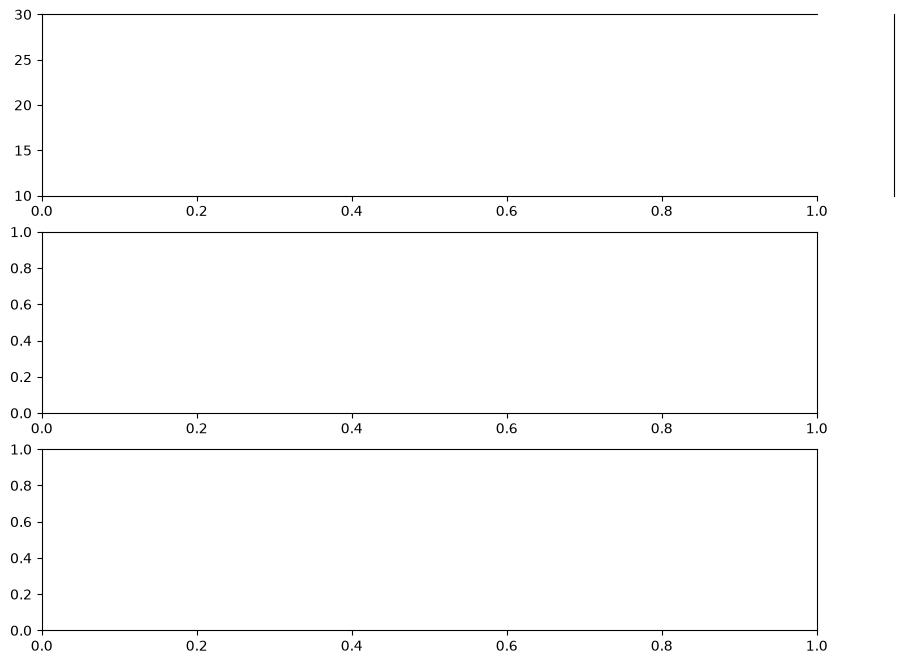

In [9]:
import MatPlotLibUtils
importlib.reload(MatPlotLibUtils)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, HTML
import importlib
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(MatPlotLibUtils)
import  datetime as _dt
from datetime import datetime, timedelta
import pandas
import geopandas as gpd

display(HTML("<style>.jp-OutputArea {max-height: 20000px;min_height: 20000px;}</style>"))

# --- colors for consistency
precip_color = "tab:blue"
temperature_color   = "crimson"


# Match Figure 9 treatment styling
ara_style = dict(
    color="darkgreen",
    linestyle="-",
    linewidth=2.5,
    marker="o",
    markersize=4
)

bsu_style = dict(
    color="peru",
    linestyle="-",
    linewidth=1.5,
    marker="s",
    markersize=4
)

weeds_style = dict(
    color="purple",
    linestyle="--",
    linewidth=1.5,
    marker="^",
    markersize=4
)

# --- plot: NDMI (left), cloud (right), DAILY precip on a second right axis
fig, axes = plt.subplots(3,figsize=(10, 8))
# NDMI lines (sparse dates)
ax=axes[0]


minTemp = 10
maxTemp = 30
myfontsize = 18
ax.set_ylim(minTemp, maxTemp)
ax.spines["right"].set_position(("axes", 1.10))  # shift outward
p["tave_10d"] = p["tavg"].rolling(window=10, min_periods=1).mean()
#ax.plot(visualcrossing_dict['datetime'], visualcrossing_dict["temp"],lw=1.5, label="T (°C)") 
dates = [datetime.strptime( day['datetime'], "%Y-%m-%d") for day in visualcrossing_dict['days']]
temperatures = [day['temp'] for day in visualcrossing_dict['days']]
precipitations = [day['precip'] for day in visualcrossing_dict['days']]
ax.plot(dates, temperatures,lw=1.5, label="T (°C)",color=temperature_color) 
#ax.plot(p["date"], p["tave_10d"],color=temperature_color, lw=1.5, label="T 10-day back-average (°C)") # takes min,max, avg
ax.set_ylabel("T (°C)",color=temperature_color,fontsize = myfontsize)

ax.grid(False)
#ax.set_ylabel("NDMI")
#ax.legend(loc="upper center")
ax.set_frame_on(True); ax.patch.set_visible(False)
MatPlotLibUtils.indicate_seasons(startDate,endDate, ax,"Dry season")

ax2 = ax.twinx()
ax2.set_ylabel("Precip (mm)",color=precip_color,fontsize = myfontsize)
ax2.bar(dates, precipitations,label="Precipitation (mm)",color=precip_color)


MatPlotLibUtils.plot_season_climate_averages(
    startDate,
    endDate,
    dates,
    temperatures,
    precipitations,
    ax,
    ax2,
    temp_color=temperature_color,
    precip_color=precip_color
)
MatPlotLibUtils.plot_longest_dry_spells(
    startDate,
    endDate,
    dates,
    precipitations,
    ax2,
    dry_threshold=1.0,
    y_position=24,
    my_color="saddlebrown",
    annotate=True
)

axes[2].set_ylabel("NDMI",fontsize = myfontsize)
#axes[2].set_ylabel("NDMI (Moisture)",fontsize = myfontsize)

ymin=-0.1
ymax=.1
axes[1].set_ylim(-.08, .5) 
axes[2].set_ylim(-.1, .3)
MatPlotLibUtils.indicate_seasons_box(startDate,endDate , axes[1],my_label="Dry season",my_color="pink",line_style="none")
MatPlotLibUtils.indicate_seasons_box(startDate,endDate,  axes[2],my_label="Dry season",my_color="pink",line_style="none")


axes[1].set_ylabel("Vegetation",fontsize = myfontsize)
axes[1].set_ylabel("GNDVI",fontsize = myfontsize)



#axes[1].set_ylim([-.1, .1])
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_woburn_soil_mine",      axes[1],bsu_style["color"], bsu_style["linestyle"],"BSU",-3,"top")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_willow",axes[1],ara_style["color"], ara_style["linestyle"],"ARA",-3,"center")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_woburn_abbey_park"  ,       axes[1],weeds_style["color"],weeds_style["linestyle"],"WEEDS",3,"center")
#MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_milpa_vecino",   axes[1],"darkorange","dotted","MAIZE",0,"center")

#stat sig difference between +-COVER
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_woburn_soil_mine"      ,axes[2],bsu_style["color"], bsu_style["linestyle"],"BSU",-3,"center")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_willow",axes[2],ara_style["color"], ara_style["linestyle"],"ARA",-3,"center")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_woburn_abbey_park"         ,axes[2],weeds_style["color"],weeds_style["linestyle"],"WEEDS",3,"top")
#MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_milpa_vecino"   ,axes[2],"darkorange","dotted","MAIZE",0,"center")

# Align x-limits to cover full  range too
xmin = min(df["date"].min(), p["date"].min())
xmax = max(df["date"].max(), p["date"].max())
axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)
axes[2].set_xlim(xmin, xmax)

axes[2].xaxis.set_minor_locator(mdates.DayLocator(interval=10))   # tick every 5 days
axes[2].xaxis.set_major_locator(mdates.DayLocator(interval=60)) 
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

axes[0].annotate("A", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
axes[1].annotate("B", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
axes[2].annotate("C", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()
fig.savefig("ndmi_temp_precipitation_plot.png", dpi=300, bbox_inches="tight")

#print ("Area of Weeds = ", (ConstantObjects.gdf_box_woburn_abbey_park.to_crs(epsg=3395)).area, " << ")
#print ("Area of Milpa2 = ", (ConstantObjects.gdf_plotMilpa2.to_crs(epsg=3395)).area, " << ")
#print ("Area of terreno_casa = ", (ConstantObjects.gdf_box_terreno_casa.to_crs(epsg=3395)).area, " << ")
print ("Area of ARA = ", (ConstantObjects.gdf_box_willow.to_crs(epsg=3395)).area, " << ")
print ("Area of BSU = ", (ConstantObjects.gdf_box_woburn_soil_mine.to_crs(epsg=3395)).area, " << ")

#print ("Area of MAIZE = ", (ConstantObjects.gdf_box_milpa_vecino.to_crs(epsg=3395)).area, " << ")

print ("in units of : ",(ConstantObjects.gdf_box_woburn_abbey_park.to_crs(epsg=3395)).crs.axis_info[0].unit_name)


2025 dry-season mean temperature = nan mean precipitation = nan
NDMI paired observations: 0
NDMI variance ARA:       nan
NDMI variance BSU:       nan
NDMI covariance ARA-BSU: nan
Variance for paired NDMI_ARA - NDMI_BSU: nan
Variance for unpaired NDMI_ARA - NDMI_BSU: nan


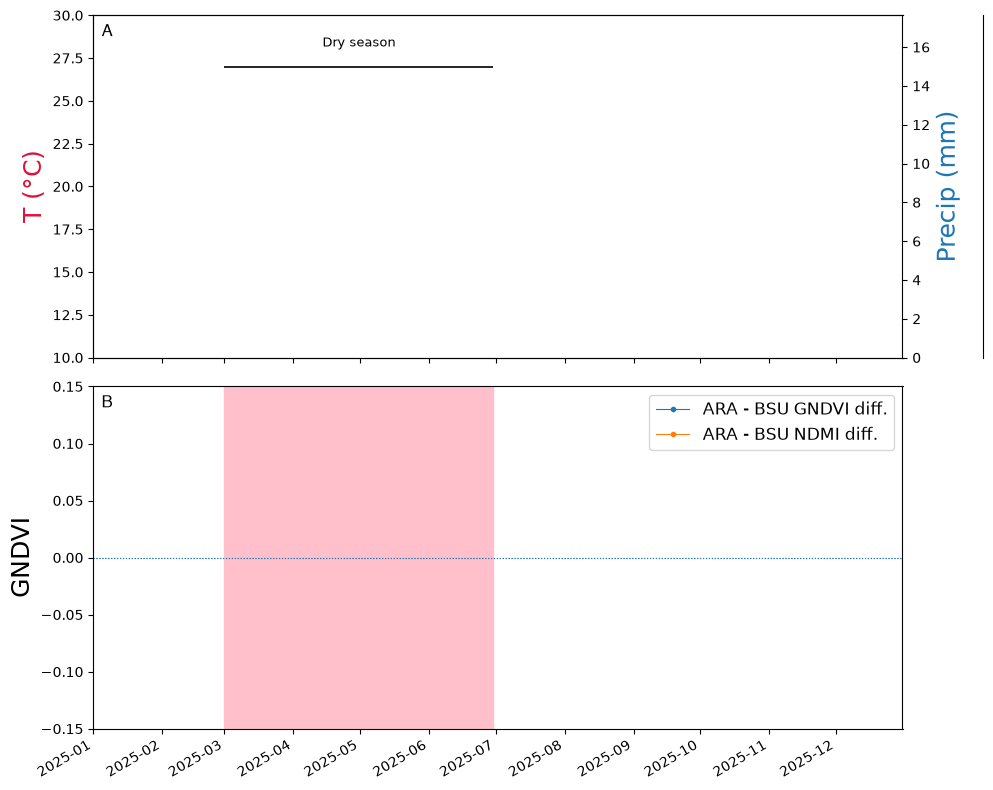

In [80]:
import MatPlotLibUtils
importlib.reload(MatPlotLibUtils)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, HTML
import importlib
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(MatPlotLibUtils)
import  datetime as _dt
from datetime import datetime, timedelta
import pandas
import geopandas as gpd

startDate2025 = "2025-01-01"
endDate2025 = "2025-12-31"



display(HTML("<style>.jp-OutputArea {max-height: 20000px;min_height: 20000px;}</style>"))

# --- colors for consistency
precip_color = "tab:blue"
temperature_color   = "crimson"

# --- plot: NDMI (left), cloud (right), DAILY precip on a second right axis
fig, axes = plt.subplots(2,figsize=(10, 8))
# NDMI lines (sparse dates)
ax=axes[0]


minTemp = 10
maxTemp = 30
myfontsize = 18
ax.set_ylim(minTemp, maxTemp)
ax.spines["right"].set_position(("axes", 1.10))  # shift outward
p["tave_10d"] = p["tavg"].rolling(window=10, min_periods=1).mean()
#ax.plot(visualcrossing_dict['datetime'], visualcrossing_dict["temp"],lw=1.5, label="T (°C)") 
dates = [datetime.strptime( day['datetime'], "%Y-%m-%d") for day in visualcrossing_dict['days']]
temperatures = [day['temp'] for day in visualcrossing_dict['days']]
precipitations = [day['precip'] for day in visualcrossing_dict['days']]
ax.plot(dates, temperatures,lw=1.5, label="T (°C)",color=temperature_color) 
ax.set_ylabel("T (°C)",color=temperature_color,fontsize = myfontsize)

ax.grid(False)
ax.set_frame_on(True); ax.patch.set_visible(False)
MatPlotLibUtils.indicate_seasons(startDate2025,endDate2025, ax,"Dry season")

ax2 = ax.twinx()
ax2.set_ylabel("Precip (mm)",color=precip_color,fontsize = myfontsize)
ax2.bar(dates, precipitations,label="Precipitation (mm)",color=precip_color)


MatPlotLibUtils.plot_season_climate_averages(
    startDate2025,
    endDate2025,
    dates,
    temperatures,
    precipitations,
    ax,
    ax2,
    temp_color=temperature_color,
    precip_color=precip_color
)
MatPlotLibUtils.plot_longest_dry_spells(
    startDate2025,
    endDate2025,
    dates,
    precipitations,
    ax2,
    dry_threshold=1.0,
    y_position=24,
    my_color="saddlebrown",
    annotate=True
)

#axes[2].set_ylabel("NDMI",fontsize = myfontsize)

ymin=-0.1
ymax=.1
axes[1].set_ylim(-.15, .15) 
#axes[2].set_ylim(-.1, .1)
MatPlotLibUtils.indicate_seasons_box(startDate2025,endDate2025 , axes[1],my_label="Dry season",my_color="pink",line_style="none")
#MatPlotLibUtils.indicate_seasons_box(startDate2025,endDate2025,  axes[2],my_label="Dry season",my_color="pink",line_style="none")


axes[1].set_ylabel("Vegetation",fontsize = myfontsize)
axes[1].set_ylabel("GNDVI",fontsize = myfontsize)

#axes[0].plot(df["date"], df["gndvi_woburn_soil_mine"],
#             marker="o", label="BSU")
#axes[0].plot(df["date"], df["gndvi_willow"],
#             marker="o", label="ARA")



# Raw acquisition-by-acquisition GNDVI difference: ARA - BSU
df2025 = df.loc[
    (df["date"] >= pandas.Timestamp(startDate2025)) &
    (df["date"] <= pandas.Timestamp(endDate2025))
].copy()

gndvi_diff = (
    df2025["gndvi_willow"]
    - df2025["gndvi_woburn_soil_mine"]
)

axes[1].plot(
    df2025["date"],
    gndvi_diff,
    marker="o",
    markersize=3,
    linewidth=0.8,
    linestyle="-",
    label="ARA - BSU GNDVI diff."
)

axes[1].axhline(0, linewidth=0.8, linestyle=":")

# Raw acquisition-by-acquisition NDMI difference: ARA - BSU
ndmi_diff = (
    df2025["ndmi_willow"]
    - df2025["ndmi_woburn_soil_mine"]
)

# --- Variance and covariance of paired ARA - BSU differences

# Combine the two difference series so that covariance uses only
# acquisitions where both NDMI and GNDVI are available.
diff_stats = pandas.DataFrame({
    "GNDVI_diff": gndvi_diff,
    "NDMI_diff": ndmi_diff
}).dropna()


########
# Determine potential for reducing statistical noise by pairing:
ndmi_stats = df2025[
    [
        "ndmi_willow",
        "ndmi_woburn_soil_mine"
    ]
].dropna()

ndmi_ara_variance = ndmi_stats["ndmi_willow"].var(ddof=1)
ndmi_bsu_variance = ndmi_stats["ndmi_woburn_soil_mine"].var(ddof=1)

ndmi_covariance = ndmi_stats[
    "ndmi_willow"
].cov(
    ndmi_stats["ndmi_woburn_soil_mine"]
)

print(f"NDMI paired observations: {len(ndmi_stats)}")
print(f"NDMI variance ARA:       {ndmi_ara_variance:.6f}")
print(f"NDMI variance BSU:       {ndmi_bsu_variance:.6f}")
print(f"NDMI covariance ARA-BSU: {ndmi_covariance:.6f}")
print(f"Variance for paired NDMI_ARA - NDMI_BSU: {ndmi_ara_variance + ndmi_bsu_variance -2*ndmi_covariance}")
print(f"Variance for unpaired NDMI_ARA - NDMI_BSU: { (ndmi_ara_variance + ndmi_bsu_variance) }")

########




axes[1].plot(
    df2025["date"],
    ndmi_diff,
    marker="o",
    markersize=3,
    linewidth=0.8,
    linestyle="-",
    label="ARA - BSU NDMI diff."
)

axes[1].axhline(0, linewidth=0.8, linestyle=":")

axes[1].legend(fontsize=12, loc="best")


# Align x-limits to cover full  range too
xmin = min(df["date"].min(), p["date"].min())
xmax = max(df["date"].max(), p["date"].max())
axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)
#axes[2].set_xlim(xmin, xmax)


# Restrict all panels to 2025
xmin = pandas.Timestamp(startDate2025)
xmax = pandas.Timestamp(endDate2025)

for ax in axes:
    ax.set_xlim(xmin, xmax)
    
axes[0].annotate("A", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
axes[1].annotate("B", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()
fig.savefig("ndmi_gndvi_temp_precipitation_diff_ara_bsu_plot.png", dpi=300, bbox_inches="tight")


In [81]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask

# ------------------------------------------------------------
# DIAGNOSTIC CELL: what drives the ARA - BSU GNDVI/NDMI differences?
# ------------------------------------------------------------

start_date = pd.Timestamp("2025-01-01")
end_date   = pd.Timestamp("2025-12-31")

ara_gdf = ConstantObjects.gdf_box_willow
bsu_gdf = ConstantObjects.gdf_box_woburn_soil_mine
weeds_gdf = ConstantObjects.gdf_box_woburn_abbey_park

def mean_band_over_aoi(raster_file, gdf):
    """Mean raster value within a GeoDataFrame AOI."""
    with rasterio.open(raster_file) as src:

        # Put AOI into raster CRS
        gdf_raster = gdf.to_crs(src.crs)

        geoms = [geom.__geo_interface__
                 for geom in gdf_raster.geometry]

        data, _ = mask(
            src,
            geoms,
            crop=True,
            filled=False
        )

        arr = data[0]

        # masked-array handling
        if np.ma.isMaskedArray(arr):
            vals = arr.compressed()
        else:
            vals = arr[np.isfinite(arr)]

        # Sentinel reflectance products commonly use 0 as nodata
        vals = vals[vals != 0]

        if len(vals) == 0:
            return np.nan

        return float(np.mean(vals))


def find_band_file(date, band):
    """
    Find the Sentinel-2 source band for the Villanueva site.
    Site is in MGRS tile 14QQG.
    """
    date_string = pd.Timestamp(date).strftime("%Y-%m-%d")
    tile = "14QQG"

    patterns = [
        f"**/{tile}_{date_string}_{band}.jp2",
        f"**/{tile}_{date_string}_{band}.tif",
        f"**/{tile}_{date_string}_{band}.tiff",
        f"**/*{tile}*{date_string}*{band}*.jp2",
        f"**/*{tile}*{date_string}*{band}*.tif",
        f"**/*{tile}*{date_string}*{band}*.tiff",
    ]

    hits = []

    for pattern in patterns:
        hits.extend(glob.glob(pattern, recursive=True))

    # remove duplicates while preserving order
    hits = list(dict.fromkeys(hits))

    hits = [
        x for x in hits
        if "ndmi" not in x.lower()
        and "gndvi" not in x.lower()
    ]

    if len(hits) == 0:
        print(f"{date_string} {band}: no 14QQG file found")
        return None

    if len(hits) > 1:
        print(f"{date_string} {band}: found {len(hits)} 14QQG files; using")
        print("   ", hits[0])

    return hits[0]

    

# Use acquisition dates that already survived your NDMI/GNDVI processing
df2025 = df.loc[
    (df["date"] >= start_date) &
    (df["date"] <= end_date)
].copy()

rows_band = []


for date in df2025["date"]:

    row = {"date": date}

    for band in ["B03", "B08", "B11"]:

        band_file = find_band_file(date, band)

        if band_file is None:
            print(f"{date.date()} {band}: file not found")
            row[f"{band}_ARA"] = np.nan
            row[f"{band}_BSU"] = np.nan
            row[f"d{band}"] = np.nan
            continue

        ara_mean = mean_band_over_aoi(band_file, ara_gdf)
        bsu_mean = mean_band_over_aoi(band_file, bsu_gdf)

        weeds_mean = mean_band_over_aoi(band_file, weeds_gdf)

        row[f"{band}_WEEDS"] = weeds_mean
        row[f"d{band}_ARA_WEEDS"] = ara_mean - weeds_mean

        row[f"{band}_ARA"] = ara_mean
        row[f"{band}_BSU"] = bsu_mean
        row[f"d{band}"] = ara_mean - bsu_mean

    rows_band.append(row)


band_df = pd.DataFrame(rows_band)


# Existing index differences
band_df["dGNDVI"] = (
    df2025["gndvi_willow"].to_numpy()
    - df2025["gndvi_woburn_soil_mine"].to_numpy()
)

band_df["dNDMI"] = (
    df2025["ndmi_willow"].to_numpy()
    - df2025["ndmi_woburn_soil_mine"].to_numpy()
)
band_df["cloudy"] = (
    df2025["cloudy"].to_numpy()
)

# ------------------------------------------------------------
# Normalize the raw-band differences before plotting.
#
# B03/B08/B11 are reflectance/DN values and GNDVI/NDMI are indices,
# so their absolute y-scales are not directly comparable.
#
# Z-scoring lets us compare whether their SHAPES track each other.
# ------------------------------------------------------------

columns = ["dB03", "dB08", "dB11", "dGNDVI", "dNDMI"]

plot_df = band_df[["date"] + columns].copy()

for col in columns:
    mean = plot_df[col].mean()
    sd = plot_df[col].std()

    if sd > 0:
        plot_df[col + "_z"] = (plot_df[col] - mean) / sd
    else:
        plot_df[col + "_z"] = np.nan


fig, ax = plt.subplots(figsize=(12, 6))

for col, label in [
    ("dB03_z",   "B03 green"),
    ("dB08_z",   "B08 NIR"),
    ("dB11_z",   "B11 SWIR"),
    ("dGNDVI_z", "GNDVI"),
    ("dNDMI_z",  "NDMI"),
]:
    ax.plot(
        plot_df["date"],
        plot_df[col],
        marker="o",
        markersize=3,
        linewidth=1,
        label=label
    )

ax.axhline(0, linewidth=0.8, linestyle=":")

ax.set_xlim(start_date, end_date)
ax.set_ylabel("Standardized ARA - BSU difference")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.2)

fig.autofmt_xdate()
fig.tight_layout()

plt.show()


# Correlation matrix: useful numerical companion to the plot
display(
    band_df[columns].corr().round(2)
)
print ("done with cell")

KeyError: "['date', 'dB03', 'dB08', 'dB11'] not in index"

In [82]:
# Add visible-scene brightness to band_df
brightness_2025 = df.loc[
    (df["date"] >= start_date) &
    (df["date"] <= end_date),
    [
        "date",
        "red_green_blue_average",
        "gndvi_willow",
        "gndvi_woburn_soil_mine",
        "gndvi_woburn_abbey_park",
        "ndmi_willow",
        "ndmi_woburn_soil_mine",
        "ndmi_woburn_abbey_park"

    ]
].copy()

nir_plot_df = band_df.merge(
    brightness_2025,
    on="date",
    how="left"
)

# band_df already supplied this column
nir_plot_df = nir_plot_df.loc[
    nir_plot_df["cloudy"] == 0
].copy()




fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)

ax_gndvi = axes[0]
ax_ndmi = axes[1]

# -----------------------------
# Panel A: GNDVI
# -----------------------------

ax_gndvi.plot(
    nir_plot_df["date"],
    nir_plot_df["gndvi_willow"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="ARA",
    **ara_style
)

ax_gndvi.plot(
    nir_plot_df["date"],
    nir_plot_df["gndvi_woburn_soil_mine"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="BSU",
    **bsu_style
)

ax_gndvi.plot(
    nir_plot_df["date"],
    nir_plot_df["gndvi_woburn_abbey_park"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="WEEDS",
    **weeds_style
)

ax_gndvi.set_ylabel("GNDVI relative to reference")
ax_gndvi.set_xlim(start_date, end_date)
ax_gndvi.axhline(0, linewidth=0.8, linestyle=":")
ax_gndvi.grid(alpha=0.2)

MatPlotLibUtils.indicate_seasons_box(
    startDate2025,
    endDate2025,
    ax_gndvi,
    my_label="Dry season",
    my_color="pink",
    line_style="none"
)

ax_gndvi.legend(loc="upper right")

ax_gndvi.annotate(
    "A",
    xy=(0, 1),
    xycoords="axes fraction",
    xytext=(0.5, -0.5),
    textcoords="offset fontsize",
    fontsize="large",
    verticalalignment="top",
    bbox=dict(facecolor="1.", edgecolor="none", pad=3.0)
)


# -----------------------------
# Panel B: NDMI
# -----------------------------

ax_ndmi.plot(
    nir_plot_df["date"],
    nir_plot_df["ndmi_willow"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="ARA",
    **ara_style
)

ax_ndmi.plot(
    nir_plot_df["date"],
    nir_plot_df["ndmi_woburn_soil_mine"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="BSU",
    **bsu_style
)

ax_ndmi.plot(
    nir_plot_df["date"],
    nir_plot_df["ndmi_woburn_abbey_park"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="WEEDS",
    **weeds_style
)

ax_ndmi.set_ylabel("NDMI relative to reference")
ax_ndmi.set_xlabel("Date")
ax_ndmi.set_xlim(start_date, end_date)
ax_ndmi.axhline(0, linewidth=0.8, linestyle=":")
ax_ndmi.grid(alpha=0.2)

MatPlotLibUtils.indicate_seasons_box(
    startDate2025,
    endDate2025,
    ax_ndmi,
    my_label="Dry season",
    my_color="pink",
    line_style="none"
)

ax_ndmi.legend(loc="upper right")

ax_ndmi.annotate(
    "B",
    xy=(0, 1),
    xycoords="axes fraction",
    xytext=(0.5, -0.5),
    textcoords="offset fontsize",
    fontsize="large",
    verticalalignment="top",
    bbox=dict(facecolor="1.", edgecolor="none", pad=3.0)
)

fig.autofmt_xdate()
fig.tight_layout()

plt.show()
fig.savefig("ndmi_gndvi_2025.png", dpi=300, bbox_inches="tight")


KeyError: 'date'

In [83]:
from scipy import stats
import pandas as pd
import numpy as np

ds_start = pd.Timestamp(Constants.warmDryStart2025)
ds_end   = pd.Timestamp(Constants.warmDryEnd2025)

indices = df.loc[
    (df["date"] >= ds_start) &
    (df["date"] <= ds_end),
    [
        "date",
        "gndvi_willow",
        "gndvi_woburn_soil_mine",
        "gndvi_woburn_abbey_park",
        "ndmi_willow",
        "ndmi_woburn_soil_mine",
        "ndmi_woburn_abbey_park"
       
    ]
].copy()

nir = band_df.loc[
    (band_df["date"] >= ds_start) &
    (band_df["date"] <= ds_end),
    [
        "date",
        "B03_ARA",
        "B03_BSU",
        "B08_ARA",
        "B08_BSU",
        "B08_WEEDS",
        "B11_ARA",
        "B11_BSU",
        "cloudy"
    ]
].copy()

ds = nir.merge(indices, on="date", how="inner")

# Exclude acquisitions already flagged as cloudy
ds = ds.loc[ds["cloudy"] == 0].copy()

print("Dry season:", ds_start.date(), "to", ds_end.date())
print()


def paired_comparison(name, ara, comparison):

    valid = pd.DataFrame({
        "ARA": ara,
        "comparison": comparison
    }).dropna()

    delta = valid["ARA"] - valid["comparison"]

    # Directional hypothesis: ARA > comparison
    t_result = stats.ttest_rel(
        valid["ARA"],
        valid["comparison"],
        alternative="greater"
    )

    w = stats.wilcoxon(
        valid["ARA"],
        valid["comparison"],
        alternative="greater"
    )

    return {
        "comparison": name,
        "n": len(delta),
        "mean_delta": delta.mean(),
        "median_delta": delta.median(),
        "ARA_higher": (delta > 0).sum(),
        "t": t_result.statistic,
        "p_one_sided": t_result.pvalue,
        "p_wilcoxon": w.pvalue
    }


results = []

# ARA - BSU
results.append(
    paired_comparison(
        "B03 Green: BSU - ARA",
        ds["B03_BSU"], 
        ds["B03_ARA"]#,
      
        #ds["B03_ARA"],
        #ds["B03_BSU"]
    )
)

results.append(
    paired_comparison(
        "B08 NIR: ARA - BSU",
        ds["B08_ARA"],
        ds["B08_BSU"]
    )
)

results.append(
    paired_comparison(
        "B11 SWIR: BSU - ARA",
        ds["B11_BSU"],
        ds["B11_ARA"]#,

        #ds["B11_ARA"],
        #ds["B11_BSU"]
    )
)

results.append(
    paired_comparison(
        "GNDVI: ARA - BSU",
        ds["gndvi_willow"],
        ds["gndvi_woburn_soil_mine"]
    )
)

results.append(
    paired_comparison(
        "GNDVI: WEEDS - BSU",
        ds["gndvi_woburn_abbey_park"],
        ds["gndvi_woburn_soil_mine"]
    )
)

results.append(
    paired_comparison(
        "NDMI: ARA - BSU",
        ds["ndmi_willow"],
        ds["ndmi_woburn_soil_mine"]
    )
)

# ARA - WEEDS
results.append(
    paired_comparison(
        "B08: ARA - WEEDS",
        ds["B08_ARA"],
        ds["B08_WEEDS"]
    )
)

results.append(
    paired_comparison(
        "NDMI: ARA - WEEDS",
        ds["ndmi_willow"],
        ds["ndmi_woburn_abbey_park"]
    )
)

results.append(
    paired_comparison(
        "GNDVI: ARA - WEEDS",
        ds["gndvi_willow"],
        ds["gndvi_woburn_abbey_park"]
    )
)



results_df = pd.DataFrame(results)

display(results_df)
results_df.to_csv("comparison-significance.csv", index=False)
#provide this as supplementary data:
ds.to_csv("dry-season-data-2025.csv", index=False)


KeyError: 'date'

In [84]:
# Got 17 rain free days in every single DS for all three years. running this diagnostic as a sanity check
for year in [2023, 2025, 2026]:

    start = pd.Timestamp(f"{year}-03-01")
    end   = pd.Timestamp(f"{year}-06-30")

    tmp = df.loc[
        (df["date"] >= start) &
        (df["date"] <= end),
        ["date", "cloudy", "red_green_blue_average"]
    ].copy()

    print("\n================")
    print(year)
    print("================")
    print("Total acquisitions:", len(tmp))
    print("Cloud-free:", (tmp["cloudy"] == 0).sum())
    print("Cloudy:", (tmp["cloudy"] == 1).sum())

    display(tmp)


2023
Total acquisitions: 0
Cloud-free: 0
Cloudy: 0


,date,cloudy,red_green_blue_average



2025
Total acquisitions: 0
Cloud-free: 0
Cloudy: 0


,date,cloudy,red_green_blue_average



2026
Total acquisitions: 1
Cloud-free: 1
Cloudy: 0


,date,cloudy,red_green_blue_average
0,2026-06-19,0,1847.861357


In [85]:
from scipy import stats
import pandas as pd
import numpy as np

# ============================================================
# Multi-year dry-season comparison table
# Years: 2023, 2025, 2026
#
# Same analysis for every year:
#   - March 1 to June 30
#   - exclude cloudy acquisitions
#   - acquisition date is the paired observation
#   - two-sided paired tests
# ============================================================

years = [2023, 2025, 2026]


def paired_comparison(year, name, plot1, plot2):

    valid = pd.DataFrame({
        "plot1": plot1,
        "plot2": plot2
    }).dropna()

    delta = valid["plot1"] - valid["plot2"]

    if len(delta) < 2:
        return {
            "Contrast": name,
            "Year": year,
            "n": len(delta),
            "Mean Δ": np.nan,
            "Δ > 0 (n)": np.nan,
            "p, paired t": np.nan,
            "p, Wilcoxon": np.nan
        }

    # Two-sided paired t-test
    t_result = stats.ttest_rel(
        valid["plot1"],
        valid["plot2"],
        alternative="two-sided"
    )

    # Two-sided Wilcoxon signed-rank test
    try:
        w_result = stats.wilcoxon(
            valid["plot1"],
            valid["plot2"],
            alternative="two-sided"
        )
        p_wilcoxon = w_result.pvalue

    except ValueError:
        p_wilcoxon = np.nan

    return {
        "Contrast": name,
        "Year": year,
        "n": len(delta),
        "Mean Δ": delta.mean(),
        "Δ > 0 (n)": int((delta > 0).sum()),
        "p, paired t": t_result.pvalue,
        "p, Wilcoxon": p_wilcoxon
    }


# ============================================================
# Run all years
# ============================================================

all_results = []

for year in years:

    ds_start = pd.Timestamp(f"{year}-03-01")
    ds_end   = pd.Timestamp(f"{year}-06-30")

    ds_year = df.loc[
        (df["date"] >= ds_start) &
        (df["date"] <= ds_end),
        [
            "date",
            "gndvi_willow",
            "gndvi_woburn_soil_mine",
            "gndvi_woburn_abbey_park",
            "ndmi_willow",
            "ndmi_woburn_soil_mine",
            "ndmi_woburn_abbey_park",
            "cloudy"
        ]
    ].copy()

    # Exclude cloudy acquisitions
    ds_year = ds_year.loc[
        ds_year["cloudy"] == 0
    ].copy()

    print(
        year,
        "non-cloudy acquisitions:",
        len(ds_year)
    )

    # --------------------------------------------------------
    # ARA - BSU
    # --------------------------------------------------------

    all_results.append(
        paired_comparison(
            year,
            "GNDVI_ARA - GNDVI_BSU",
            ds_year["gndvi_willow"],
            ds_year["gndvi_woburn_soil_mine"]
        )
    )

    all_results.append(
        paired_comparison(
            year,
            "NDMI_ARA - NDMI_BSU",
            ds_year["ndmi_willow"],
            ds_year["ndmi_woburn_soil_mine"]
        )
    )

    # --------------------------------------------------------
    # ARA - WEEDS
    # --------------------------------------------------------

    all_results.append(
        paired_comparison(
            year,
            "GNDVI_ARA - GNDVI_WEEDS",
            ds_year["gndvi_willow"],
            ds_year["gndvi_woburn_abbey_park"]
        )
    )

    all_results.append(
        paired_comparison(
            year,
            "NDMI_ARA - NDMI_WEEDS",
            ds_year["ndmi_willow"],
            ds_year["ndmi_woburn_abbey_park"]
        )
    )


# ============================================================
# Compact manuscript-style table
# ============================================================

table_df = pd.DataFrame(all_results)

# Keep the years together within each contrast
contrast_order = [
    "GNDVI_ARA - GNDVI_BSU",
    "NDMI_ARA - NDMI_BSU",
    "GNDVI_ARA - GNDVI_WEEDS",
    "NDMI_ARA - NDMI_WEEDS"
]

table_df["Contrast"] = pd.Categorical(
    table_df["Contrast"],
    categories=contrast_order,
    ordered=True
)

table_df = table_df.sort_values(
    ["Contrast", "Year"]
).reset_index(drop=True)

# Fewer significant figures for manuscript display
table_df["Mean Δ"] = table_df["Mean Δ"].map(
    lambda x: f"{x:.2g}" if pd.notna(x) else ""
)

table_df["p, paired t"] = table_df["p, paired t"].map(
    lambda x: f"{x:.1E}" if pd.notna(x) else ""
)

table_df["p, Wilcoxon"] = table_df["p, Wilcoxon"].map(
    lambda x: f"{x:.1E}" if pd.notna(x) else ""
)

display(table_df)

# Optional export
table_df.to_csv(
    "dry-season-GNDVI-NDMI-comparisons-2023-2025-2026.csv",
    index=False
)

2023 non-cloudy acquisitions: 0
2025 non-cloudy acquisitions: 0
2026 non-cloudy acquisitions: 1


,Contrast,Year,n,Mean Δ,Δ > 0 (n),"p, paired t","p, Wilcoxon"
0,GNDVI_ARA - GNDVI_BSU,2023,0,,NaN,,
1,GNDVI_ARA - GNDVI_BSU,2025,0,,NaN,,
2,GNDVI_ARA - GNDVI_BSU,2026,1,,NaN,,
3,NDMI_ARA - NDMI_BSU,2023,0,,NaN,,
4,NDMI_ARA - NDMI_BSU,2025,0,,NaN,,
5,NDMI_ARA - NDMI_BSU,2026,1,,NaN,,
6,GNDVI_ARA - GNDVI_WEEDS,2023,0,,NaN,,
7,GNDVI_ARA - GNDVI_WEEDS,2025,0,,NaN,,
8,GNDVI_ARA - GNDVI_WEEDS,2026,1,,NaN,,
9,NDMI_ARA - NDMI_WEEDS,2023,0,,NaN,,


In [86]:


from scipy import stats
import pandas as pd
import numpy as np

# ============================================================
# BACI analysis for dry-season GNDVI and NDMI
#
# BEFORE: pooled dry-season acquisitions from 2022 + 2023
# AFTER:  2025 dry-season acquisitions
#
# For each acquisition:
#   d_t = value_plot1,t - value_plot2,t
#
# BACI = mean(d_after) - mean(d_before)
#
# Significance:
#   - Welch's independent two-sample t-test
#   - Wilcoxon rank-sum equivalent: Mann-Whitney U
#
# Cloudy acquisitions are excluded before constructing contrasts.
# ============================================================

before_years = [2022, 2023]
after_year = 2026


def get_dry_season(year):
    """Return cloud-free March 1-June 30 acquisitions for one year."""

    ds_start = pd.Timestamp(f"{year}-03-01")
    ds_end   = pd.Timestamp(f"{year}-06-30")

    ds = df.loc[
        (df["date"] >= ds_start) &
        (df["date"] <= ds_end),
        [
            "date",
            "gndvi_willow",
            "gndvi_woburn_soil_mine",
            "gndvi_woburn_abbey_park",
            "ndmi_willow",
            "ndmi_woburn_soil_mine",
            "ndmi_woburn_abbey_park",
            "cloudy"
        ]
    ].copy()

    ds = ds.loc[
        ds["cloudy"] == 0
    ].copy()

    ds["year"] = year

    return ds


def make_scene_contrast(ds, plot1_col, plot2_col):
    """
    Construct the within-scene spatial contrast:
        d_t = plot1_t - plot2_t
    """

    valid = ds[
        ["date", plot1_col, plot2_col]
    ].dropna().copy()

    valid["d"] = (
        valid[plot1_col] -
        valid[plot2_col]
    )

    return valid["d"].to_numpy()


def baci_comparison(
    name,
    before_df,
    after_df,
    plot1_col,
    plot2_col
):

    # --------------------------------------------------------
    # First construct paired spatial contrasts within each scene
    # --------------------------------------------------------

    d_before = make_scene_contrast(
        before_df,
        plot1_col,
        plot2_col
    )

    d_after = make_scene_contrast(
        after_df,
        plot1_col,
        plot2_col
    )

    if len(d_before) < 2 or len(d_after) < 2:
        return {
            "Contrast": name,
            "n before": len(d_before),
            "n after": len(d_after),
            "Mean Δ before": np.nan,
            "Mean Δ after": np.nan,
            "BACI": np.nan,
            "p, Welch": np.nan,
            "p, rank-sum": np.nan
        }

    # --------------------------------------------------------
    # BACI effect
    # --------------------------------------------------------

    mean_before = np.mean(d_before)
    mean_after  = np.mean(d_after)

    baci = mean_after - mean_before

    # --------------------------------------------------------
    # Welch's independent two-sample t-test
    #
    # Tests whether the mean within-scene contrast changed
    # between BEFORE and AFTER.
    # --------------------------------------------------------

    welch = stats.ttest_ind(
        d_after,
        d_before,
        equal_var=False,
        alternative="two-sided"
    )

    # --------------------------------------------------------
    # Non-parametric comparison:
    # Mann-Whitney U = Wilcoxon rank-sum test
    #
    # Unlike the old analysis, this is NOT signed-rank,
    # because BEFORE and AFTER are independent samples.
    # --------------------------------------------------------

    try:
        rank_sum = stats.mannwhitneyu(
            d_after,
            d_before,
            alternative="two-sided",
            method="auto"
        )
        p_rank_sum = rank_sum.pvalue

    except ValueError:
        p_rank_sum = np.nan

    return {
        "Contrast": name,
        "n before": len(d_before),
        "n after": len(d_after),
        "Mean Δ before": mean_before,
        "Mean Δ after": mean_after,
        "BACI": baci,
        "p, Welch": welch.pvalue,
        "p, rank-sum": p_rank_sum
    }


# ============================================================
# Build BEFORE and AFTER datasets
# ============================================================

before_parts = []

for year in before_years:
    ds_year = get_dry_season(year)

    print(
        year,
        "non-cloudy acquisitions:",
        len(ds_year)
    )

    before_parts.append(ds_year)


before_df = pd.concat(
    before_parts,
    ignore_index=True
)

after_df = get_dry_season(after_year)

print(
    after_year,
    "non-cloudy acquisitions:",
    len(after_df)
)

print()
print(
    "Pooled BEFORE acquisitions:",
    len(before_df)
)

print(
    "AFTER acquisitions:",
    len(after_df)
)


# ============================================================
# Run BACI contrasts
# ============================================================

results = []

# ------------------------------------------------------------
# ARA - BSU
# ------------------------------------------------------------

results.append(
    baci_comparison(
        "GNDVI_ARA - GNDVI_BSU",
        before_df,
        after_df,
        "gndvi_willow",
        "gndvi_woburn_soil_mine"
    )
)

results.append(
    baci_comparison(
        "NDMI_ARA - NDMI_BSU",
        before_df,
        after_df,
        "ndmi_willow",
        "ndmi_woburn_soil_mine"
    )
)

# ------------------------------------------------------------
# ARA - WEEDS
# ------------------------------------------------------------

results.append(
    baci_comparison(
        "GNDVI_ARA - GNDVI_WEEDS",
        before_df,
        after_df,
        "gndvi_willow",
        "gndvi_woburn_abbey_park"
    )
)

results.append(
    baci_comparison(
        "NDMI_ARA - NDMI_WEEDS",
        before_df,
        after_df,
        "ndmi_willow",
        "ndmi_woburn_abbey_park"
    )
)


# ============================================================
# Compact manuscript-style table
# ============================================================

table_df = pd.DataFrame(results)

contrast_order = [
    "GNDVI_ARA - GNDVI_BSU",
    "NDMI_ARA - NDMI_BSU",
    "GNDVI_ARA - GNDVI_WEEDS",
    "NDMI_ARA - NDMI_WEEDS"
]

table_df["Contrast"] = pd.Categorical(
    table_df["Contrast"],
    categories=contrast_order,
    ordered=True
)

table_df = table_df.sort_values(
    "Contrast"
).reset_index(drop=True)


# ------------------------------------------------------------
# Compact formatting
# ------------------------------------------------------------

for col in [
    "Mean Δ before",
    "Mean Δ after",
    "BACI"
]:
    table_df[col] = table_df[col].map(
        lambda x: f"{x:.2g}" if pd.notna(x) else ""
    )

for col in [
    "p, Welch",
    "p, rank-sum"
]:
    table_df[col] = table_df[col].map(
        lambda x: f"{x:.1E}" if pd.notna(x) else ""
    )


display(table_df)


# ============================================================
# Optional export
# ============================================================

table_df.to_csv(
    "BACI-dry-season-GNDVI-NDMI-2025-vs-2022-2023.csv",
    index=False
)



2022 non-cloudy acquisitions: 0
2023 non-cloudy acquisitions: 0
2026 non-cloudy acquisitions: 1

Pooled BEFORE acquisitions: 0
AFTER acquisitions: 1


,Contrast,n before,n after,Mean Δ before,Mean Δ after,BACI,"p, Welch","p, rank-sum"
0,GNDVI_ARA - GNDVI_BSU,0,1,,,,,
1,NDMI_ARA - NDMI_BSU,0,1,,,,,
2,GNDVI_ARA - GNDVI_WEEDS,0,1,,,,,
3,NDMI_ARA - NDMI_WEEDS,0,1,,,,,


KeyError: 'gndvi_milpa_vecino'

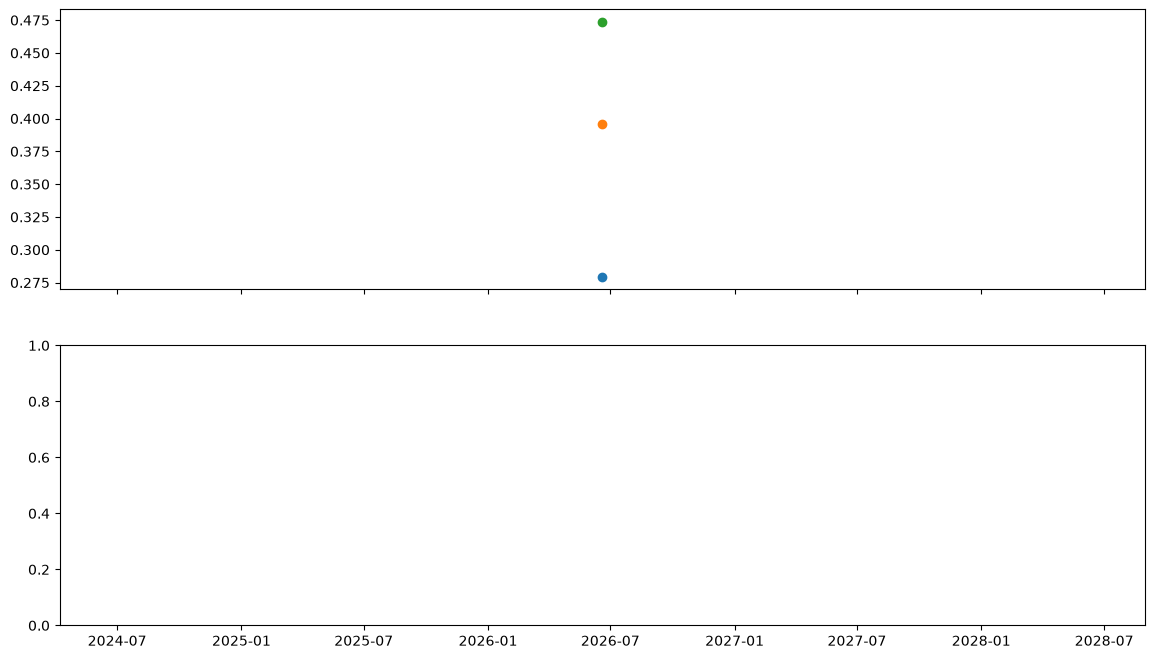

In [87]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# GNDVI
axes[0].plot(df["date"], df["gndvi_woburn_soil_mine"],
             marker="o", label="BSU")
axes[0].plot(df["date"], df["gndvi_willow"],
             marker="o", label="ARA")
axes[0].plot(df["date"], df["gndvi_woburn_abbey_park"],
             marker="o", label="WEEDS")
axes[0].plot(df["date"], df["gndvi_milpa_vecino"],
             marker="o", label="MAIZE")

axes[0].set_ylabel("GNDVI")
axes[0].legend()
axes[0].grid(alpha=0.2)

# NDMI
axes[1].plot(df["date"], df["ndmi_woburn_soil_mine"],
             marker="o", label="BSU")
axes[1].plot(df["date"], df["ndmi_willow"],
             marker="o", label="ARA")
axes[1].plot(df["date"], df["ndmi_woburn_abbey_park"],
             marker="o", label="WEEDS")
#axes[1].plot(df["date"], df["ndmi_milpa_vecino"],
#             marker="o", label="MAIZE")

axes[1].set_ylabel("NDMI")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(alpha=0.2)




In [127]:
ndmi_analysis = df.loc[
    (df["date"] >= "2022-01-03") &
    (df["date"] <= "2026-07-31"),
    [
        "date",
        "ndmi_willow",
        "ndmi_woburn_soil_mine",
        "ndmi_woburn_abbey_park",

        "gndvi_willow",
        "gndvi_woburn_soil_mine",
        "gndvi_woburn_abbey_park"
    ]
].copy()

ndmi_analysis = ndmi_analysis.rename(columns={
    "ndmi_willow": "ARA_NDMI",
    "ndmi_woburn_soil_mine": "BSU_NDMI",
    "ndmi_woburn_abbey_park": "WEEDS_NDMI",

    "gndvi_willow": "ARA_GNDVI",
    "gndvi_woburn_soil_mine": "BSU_GNDVI",
    "gndvi_woburn_abbey_park": "WEEDS_GNDVI"
})



ndmi_analysis.to_csv(
    "ndmi-gndvi-2022-2026.csv",
    index=False
)